In [9]:
# Install required packages (run once)
!pip install yfinance ta plotly xgboost tensorflow joblib scikit-learn matplotlib seaborn pandas numpy -q

  Preparing metadata (setup.py) ... done


In [10]:
# Configure notebook for displaying plots
%matplotlib inline
import plotly.io as pio
pio.renderers.default = 'notebook'

In [11]:
# Import essential libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import ta # Technical indicators

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Configure Plotly for notebook
pio.renderers.default = 'notebook'

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"Current Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully!
Current Date: 2025-12-06 10:52:11


## Data Loading from Yahoo Finance

In [12]:
def load_stock_data(ticker='AMZN', start_date='2010-01-01', end_date='2024-01-01'):

    print(f"Downloading {ticker} stock data from {start_date} to {end_date}...")
    
    try:
        # Download data using yf.download()
        df = yf.download(ticker, start=start_date, end=end_date)
        
        # Check if data was retrieved
        if df.empty:
            raise ValueError(f"No data found for ticker: {ticker}")
        
        # Flatten multi-index columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        # Reset index to make Date a column
        df.reset_index(inplace=True)
        
        # Remove timezone info if present
        if df['Date'].dt.tz is not None:
            df['Date'] = df['Date'].dt.tz_localize(None)
        
        # Keep only required columns
        df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
        
        print(f"Successfully loaded {len(df)} rows of data")
        print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
        
        return df
    
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None

In [13]:
# Amazon stock data
ticker = 'AMZN'  # Change this to any ticker: 'AAPL', 'TSLA', 'GOOGL', 'RELIANCE.NS', etc.
start_date = '2010-01-01'  # Start date
end_date = '2024-01-01'    # End date

df = load_stock_data(ticker=ticker, start_date=start_date, end_date=end_date)

print(f"\nDataset Info:")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Successfully loaded 3522 rows of data
Date Range: 2010-01-04 to 2023-12-29

Dataset Info:
Shape: (3522, 6)

First 5 rows:


Price,Date,Open,High,Low,Close,Volume
0,2010-01-04,6.8125,6.8305,6.6570,6.6950,151998000
1,2010-01-05,6.6715,6.7740,6.5905,6.7345,177038000
2,2010-01-06,6.7300,6.7365,6.5825,6.6125,143576000
3,2010-01-07,6.6005,6.6160,6.4400,6.5000,220604000
4,2010-01-08,6.5280,6.6840,6.4515,6.6760,196610000


## Data Preprocessing

In [14]:
def preprocess_data(df):

    df_clean = df.copy()
    
    # Check for missing values
    print(f"\nMissing values before cleaning:")
    print(df_clean.isnull().sum())
    
    # Forward fill for price data (use previous valid value)
    df_clean[['Open', 'High', 'Low', 'Close']] = df_clean[['Open', 'High', 'Low', 'Close']].fillna(method='ffill')
    
    # Fill remaining NaN with backward fill
    df_clean = df_clean.fillna(method='bfill')
    
    # Drop any remaining NaN rows
    df_clean.dropna(inplace=True)
    
    # Ensure Date is datetime type
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    
    # Sort by date
    df_clean.sort_values('Date', inplace=True)
    df_clean.reset_index(drop=True, inplace=True)
    
    # Check for missing values after cleaning
    print(f"\nMissing values after cleaning:")
    print(df_clean.isnull().sum())
    
    print(f"\nFinal dataset shape: {df_clean.shape}")
    
    return df_clean

In [15]:
# Preprocess the data
df_clean = preprocess_data(df)
print("\nCleaned Data Summary:")
df_clean.describe()


Missing values before cleaning:
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Missing values after cleaning:
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Final dataset shape: (3522, 6)

Cleaned Data Summary:


Price,Date,Open,High,Low,Close,Volume
count,3522,3522.000000,3522.000000,3522.000000,3522.000000,3.522000e+03
mean,2016-12-30 22:57:51.209540096,63.364224,64.100841,62.560762,63.346506,8.623848e+07
min,2010-01-04 00:00:00,5.296500,5.564500,5.290000,5.430500,1.762600e+07
25%,2013-07-03 12:00:00,14.112500,14.248625,13.990250,14.125375,5.470450e+07
50%,2016-12-29 12:00:00,40.960001,41.091249,40.674999,40.906000,7.274100e+07
75%,2020-06-30 18:00:00,99.859627,100.972498,98.246874,99.844875,1.011300e+08
max,2023-12-29 00:00:00,187.199997,188.654007,184.839493,186.570496,8.484220e+08
std,NaN,54.802980,55.461393,54.082369,54.767164,5.202895e+07


## Feature Engineering - Technical Indicators

In [17]:
def add_technical_indicators(df):
    
    df_features = df.copy()
    
    # 1. MOVING AVERAGES
    df_features['MA7'] = df_features['Close'].rolling(window=7).mean()
    df_features['MA21'] = df_features['Close'].rolling(window=21).mean()
    df_features['MA50'] = df_features['Close'].rolling(window=50).mean()
    df_features['MA200'] = df_features['Close'].rolling(window=200).mean()
    print("Added Moving Averages (7, 21, 50, 200)")
    
    # 2. EXPONENTIAL MOVING AVERAGE
    df_features['EMA12'] = df_features['Close'].ewm(span=12, adjust=False).mean()
    print("Added Exponential Moving Average (12)")
    
    # 3. RSI (Relative Strength Index)
    df_features['RSI'] = ta.momentum.RSIIndicator(
        close=df_features['Close'], 
        window=14
    ).rsi()
    print("Added RSI (14)")
    
    # 4. MACD (Moving Average Convergence Divergence)
    macd = ta.trend.MACD(
        close=df_features['Close'],
        window_slow=26,
        window_fast=12,
        window_sign=9
    )
    df_features['MACD'] = macd.macd()
    df_features['MACD_Signal'] = macd.macd_signal()
    df_features['MACD_Diff'] = macd.macd_diff()
    print("Added MACD (12-26-9)")
    
    # 5. BOLLINGER BANDS
    bollinger = ta.volatility.BollingerBands(
        close=df_features['Close'],
        window=20,
        window_dev=2
    )
    df_features['BB_Upper'] = bollinger.bollinger_hband()
    df_features['BB_Lower'] = bollinger.bollinger_lband()
    df_features['BB_Middle'] = bollinger.bollinger_mavg()
    print("Added Bollinger Bands (20, 2)")
    
    # 6. DAILY RETURNS
    df_features['Daily_Return'] = df_features['Close'].pct_change()
    print("Added Daily Returns")
    
    # 7. VOLATILITY (20-day rolling standard deviation)
    df_features['Volatility'] = df_features['Close'].rolling(window=20).std()
    print("Added Volatility (20)")
    
    # 8. LAG FEATURES (Close_1 to Close_30)
    for i in range(1, 31):
        df_features[f'Close_{i}'] = df_features['Close'].shift(i)
    print("Added Lag Features (Close_1 to Close_30)")
    
    # 9. TARGET VARIABLE FOR XGBOOST (Classification: Up=1, Down=0)
    df_features['Target_XGB'] = (df_features['Close'].shift(-1) > df_features['Close']).astype(int)
    print("Added Target for XGBoost Classification")
    
    # 10. TARGET VARIABLE FOR LSTM (Next day's closing price)
    df_features['Target_LSTM'] = df_features['Close'].shift(-1)
    print("Added Target for LSTM Regression")
    
    # Drop rows with NaN values created by rolling windows and lag features
    initial_rows = len(df_features)
    df_features.dropna(inplace=True)
    df_features.reset_index(drop=True, inplace=True)
    
    rows_dropped = initial_rows - len(df_features)
    print(f"\nDropped {rows_dropped} rows with NaN values")
    print(f"Final feature-engineered dataset: {df_features.shape}")
    print(f"Total features: {len(df_features.columns)}")
    
    return df_features

In [18]:
# Add technical indicators
df_features = add_technical_indicators(df_clean)

# Display feature columns
print("\nFeature Columns:")
print(df_features.columns.tolist())

print("\nSample Data with Features:")
df_features.tail()

Added Moving Averages (7, 21, 50, 200)
Added Exponential Moving Average (12)
Added RSI (14)
Added MACD (12-26-9)
Added Bollinger Bands (20, 2)
Added Daily Returns
Added Volatility (20)
Added Lag Features (Close_1 to Close_30)
Added Target for XGBoost Classification
Added Target for LSTM Regression

Dropped 200 rows with NaN values
Final feature-engineered dataset: (3322, 52)
Total features: 52

Feature Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA21', 'MA50', 'MA200', 'EMA12', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff', 'BB_Upper', 'BB_Lower', 'BB_Middle', 'Daily_Return', 'Volatility', 'Close_1', 'Close_2', 'Close_3', 'Close_4', 'Close_5', 'Close_6', 'Close_7', 'Close_8', 'Close_9', 'Close_10', 'Close_11', 'Close_12', 'Close_13', 'Close_14', 'Close_15', 'Close_16', 'Close_17', 'Close_18', 'Close_19', 'Close_20', 'Close_21', 'Close_22', 'Close_23', 'Close_24', 'Close_25', 'Close_26', 'Close_27', 'Close_28', 'Close_29', 'Close_30', 'Target_XGB', 'Target_LSTM']

Sa

Price,Date,Open,High,Low,Close,Volume,MA7,MA21,MA50,MA200,...,Close_23,Close_24,Close_25,Close_26,Close_27,Close_28,Close_29,Close_30,Target_XGB,Target_LSTM
3317,2023-12-21,153.300003,153.970001,152.100006,153.839996,36305700,151.435713,148.171905,140.8212,126.23875,...,145.179993,142.830002,143.199997,145.800003,142.589996,143.559998,140.600006,142.080002,0,153.419998
3318,2023-12-22,153.770004,154.350006,152.710007,153.419998,29514100,152.089999,148.491428,141.2430,126.54460,...,146.130005,145.179993,142.830002,143.199997,145.800003,142.589996,143.559998,140.600006,0,153.410004
3319,2023-12-26,153.559998,153.979996,153.029999,153.410004,25067200,152.945714,148.809047,141.7154,126.85800,...,143.899994,146.130005,145.179993,142.830002,143.199997,145.800003,142.589996,143.559998,0,153.339996
3320,2023-12-27,153.559998,154.779999,153.119995,153.339996,31434700,153.427141,149.076190,142.1312,127.16255,...,146.710007,143.899994,146.130005,145.179993,142.830002,143.199997,145.800003,142.589996,1,153.380005
3321,2023-12-28,153.720001,154.080002,152.949997,153.380005,27057000,153.328570,149.378571,142.5694,127.45505,...,146.740005,146.710007,143.899994,146.130005,145.179993,142.830002,143.199997,145.800003,0,151.940002


## Data Visualization

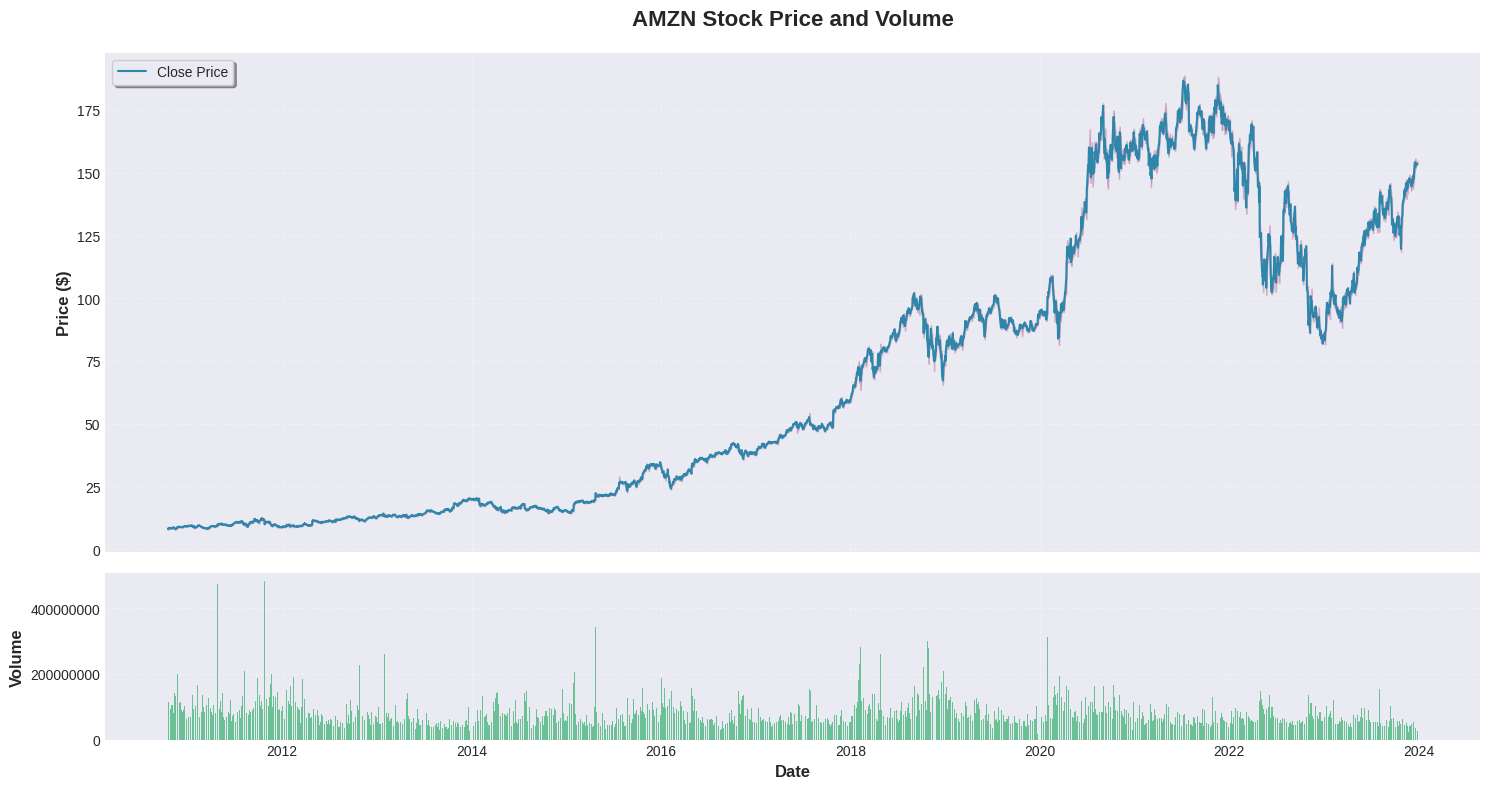

Price History with Volume


In [48]:
# 1. Price History with Volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Price chart
ax1.plot(df_features['Date'], df_features['Close'], label='Close Price', color='#2E86AB', linewidth=1.5)
ax1.fill_between(df_features['Date'], df_features['Low'], df_features['High'], alpha=0.3, color='#A23B72')
ax1.set_title(f'{ticker} Stock Price and Volume', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')

# Volume chart
ax2.bar(df_features['Date'], df_features['Volume'], color='#18A558', alpha=0.6, width=1)
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volume', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()
print("Price History with Volume")

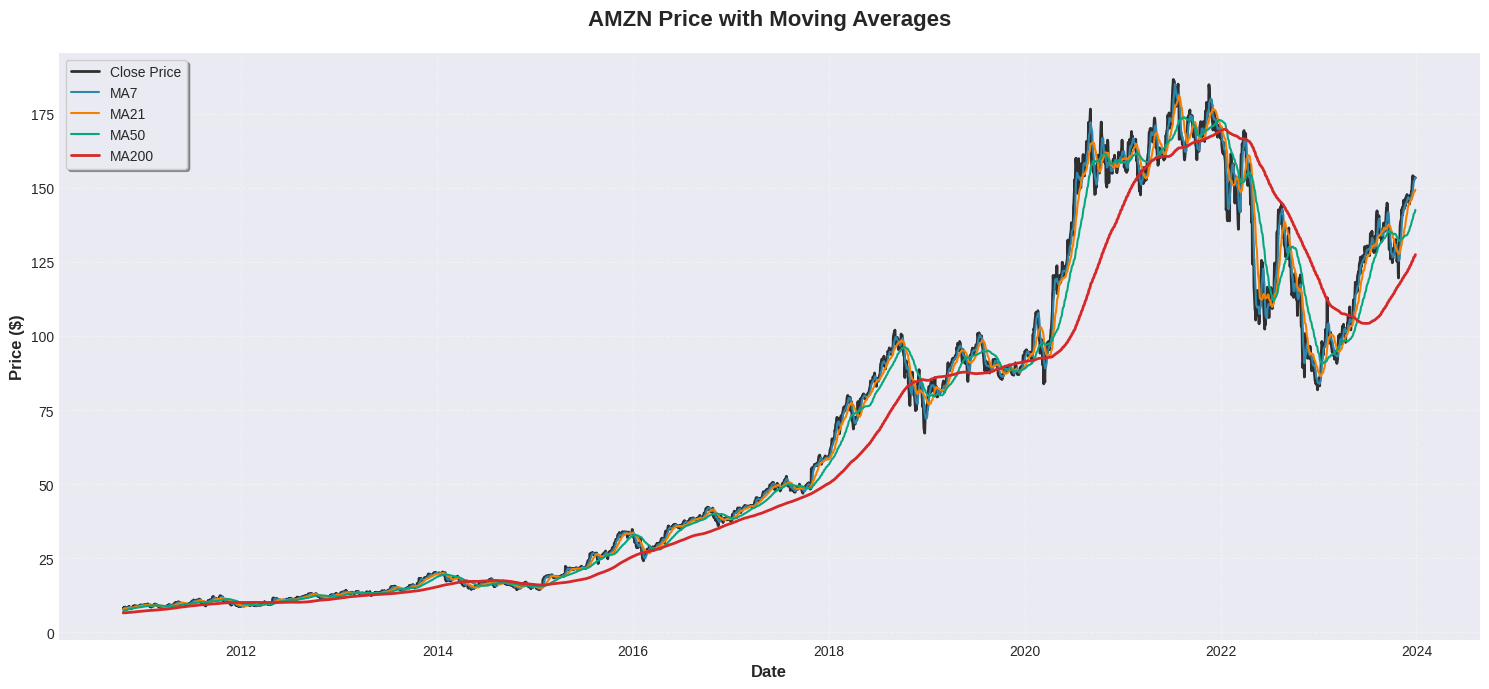

Moving Averages


In [50]:
# 2. Moving Averages
plt.figure(figsize=(15, 7))

plt.plot(df_features['Date'], df_features['Close'], label='Close Price', color='black', linewidth=2, alpha=0.8)
plt.plot(df_features['Date'], df_features['MA7'], label='MA7', color='#2E86AB', linewidth=1.5)
plt.plot(df_features['Date'], df_features['MA21'], label='MA21', color='#F77F00', linewidth=1.5)
plt.plot(df_features['Date'], df_features['MA50'], label='MA50', color='#06A77D', linewidth=1.5)
plt.plot(df_features['Date'], df_features['MA200'], label='MA200', color='#D62828', linewidth=2)

plt.title(f'{ticker} Price with Moving Averages', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("Moving Averages")

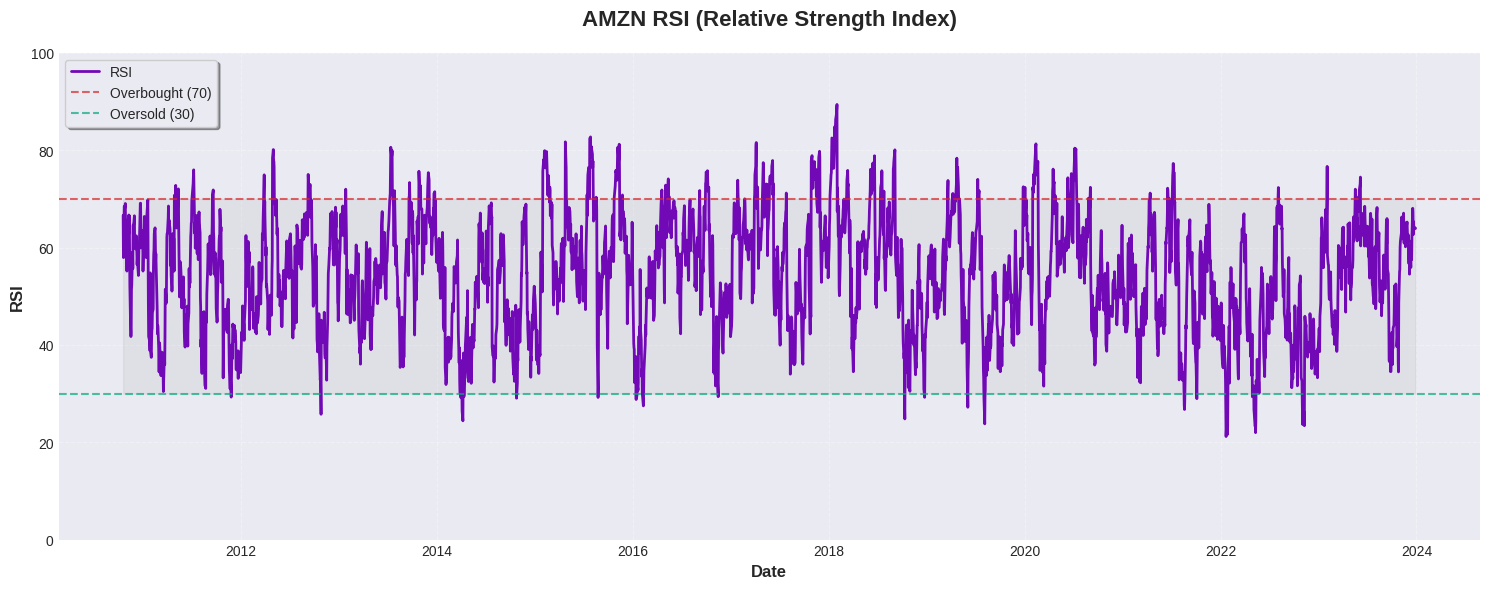

RSI Indicator


In [51]:
# 3. RSI Indicator
plt.figure(figsize=(15, 6))

plt.plot(df_features['Date'], df_features['RSI'], label='RSI', color='#7209B7', linewidth=2)
plt.axhline(y=70, color='#D62828', linestyle='--', linewidth=1.5, label='Overbought (70)', alpha=0.7)
plt.axhline(y=30, color='#06A77D', linestyle='--', linewidth=1.5, label='Oversold (30)', alpha=0.7)
plt.fill_between(df_features['Date'], 30, 70, alpha=0.1, color='gray')

plt.title(f'{ticker} RSI (Relative Strength Index)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('RSI', fontsize=12, fontweight='bold')
plt.ylim(0, 100)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("RSI Indicator")

Exception ignored in: <function _xla_gc_callback at 0x7f60df3af560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


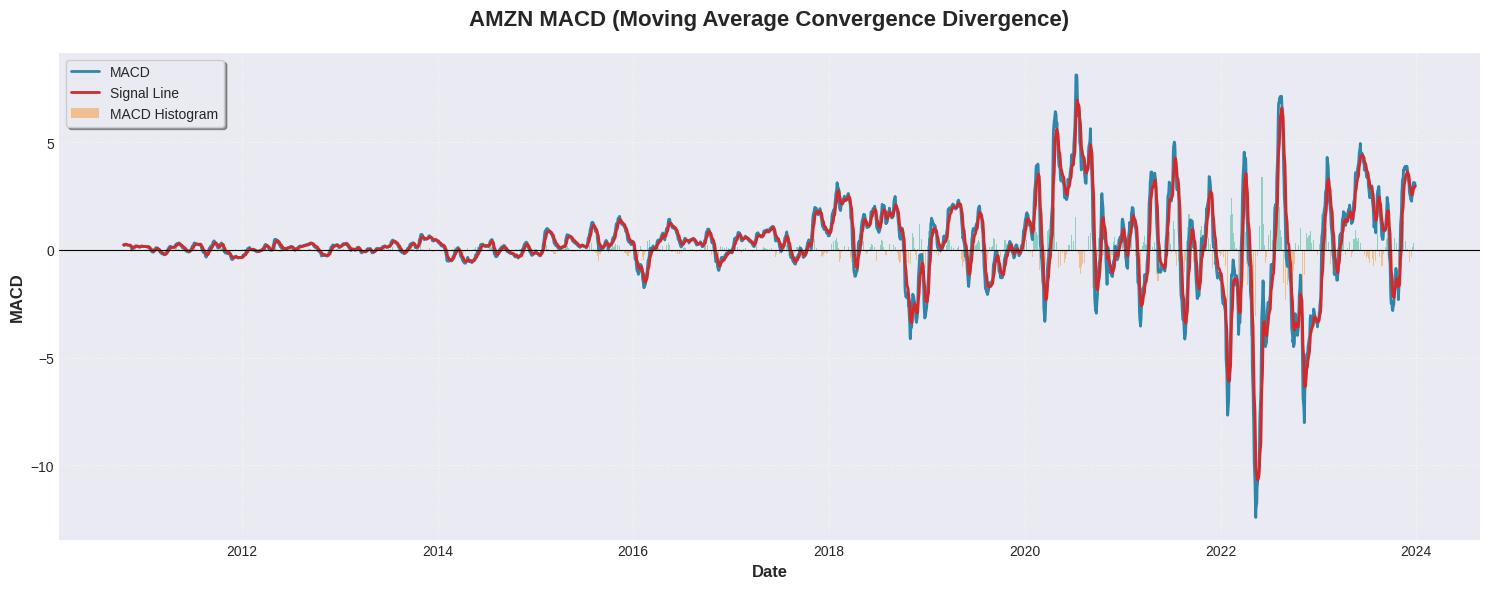

MACD Indicator


In [52]:
# 4. MACD Indicator
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df_features['Date'], df_features['MACD'], label='MACD', color='#2E86AB', linewidth=2)
ax.plot(df_features['Date'], df_features['MACD_Signal'], label='Signal Line', color='#D62828', linewidth=2)
colors = ['#06A77D' if x > 0 else '#F77F00' for x in df_features['MACD_Diff']]
ax.bar(df_features['Date'], df_features['MACD_Diff'], label='MACD Histogram', color=colors, alpha=0.4, width=1)

ax.set_title(f'{ticker} MACD (Moving Average Convergence Divergence)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('MACD', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()
print("MACD Indicator")

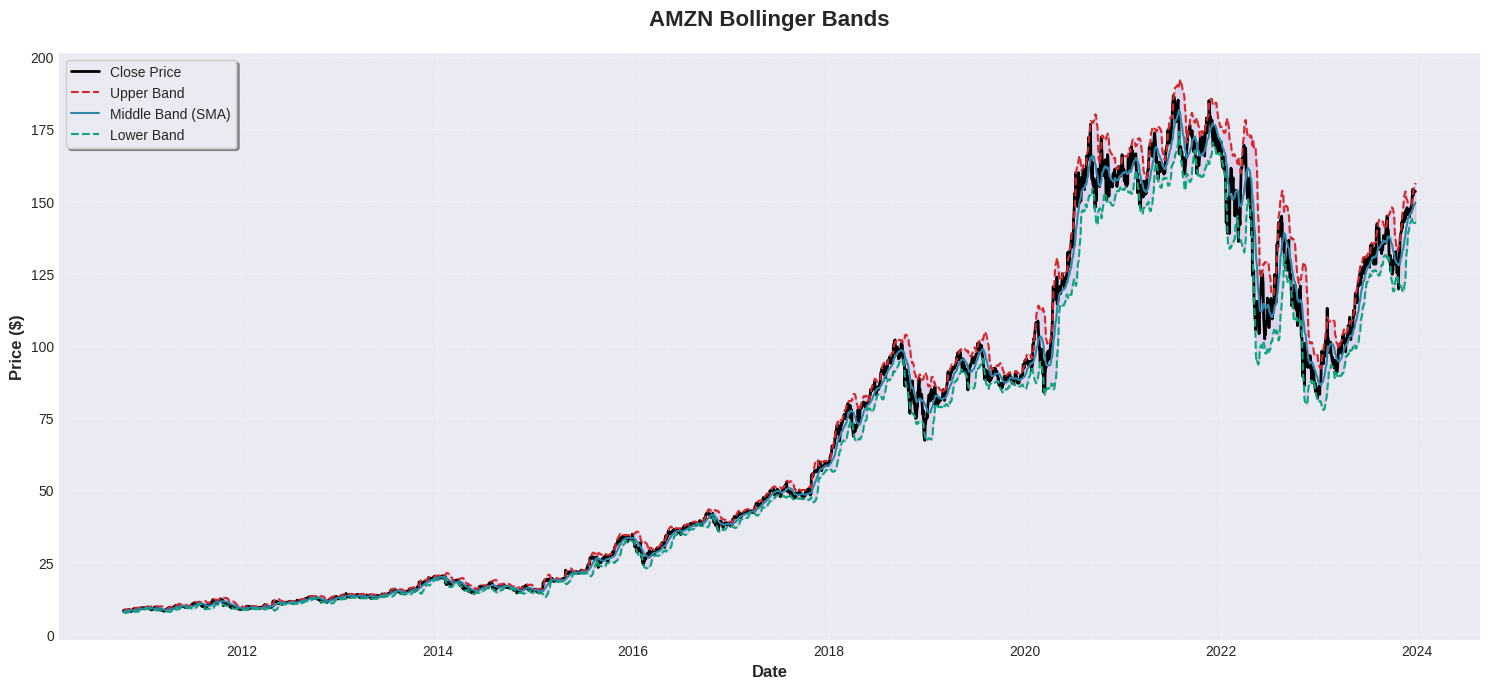

Bollinger Bands


In [53]:
# 5. Bollinger Bands
plt.figure(figsize=(15, 7))

plt.plot(df_features['Date'], df_features['Close'], label='Close Price', color='black', linewidth=2)
plt.plot(df_features['Date'], df_features['BB_Upper'], label='Upper Band', color='#D62828', linestyle='--', linewidth=1.5)
plt.plot(df_features['Date'], df_features['BB_Middle'], label='Middle Band (SMA)', color='#2E86AB', linewidth=1.5)
plt.plot(df_features['Date'], df_features['BB_Lower'], label='Lower Band', color='#06A77D', linestyle='--', linewidth=1.5)
plt.fill_between(df_features['Date'], df_features['BB_Lower'], df_features['BB_Upper'], alpha=0.1, color='#7209B7')

plt.title(f'{ticker} Bollinger Bands', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("Bollinger Bands")

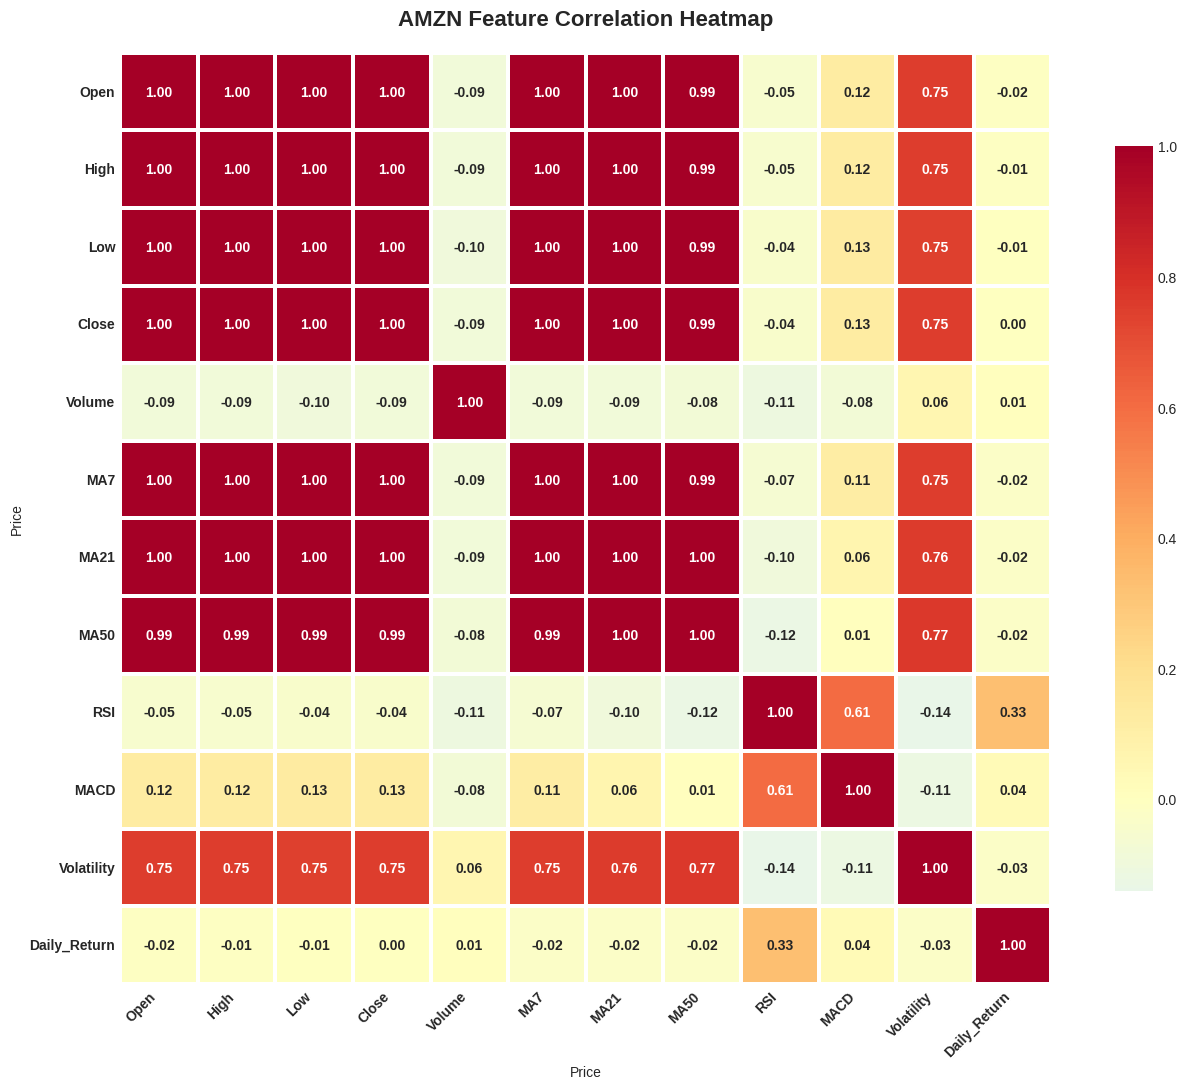

Correlation Heatmap


In [54]:
# 6. Correlation Heatmap
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 
                'MA7', 'MA21', 'MA50', 'RSI', 'MACD', 'Volatility', 'Daily_Return']

plt.figure(figsize=(14, 11))
correlation_matrix = df_features[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, 
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8}, 
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title(f'{ticker} Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation Heatmap")

## Save Processed Data for Model Training

In [26]:
# Save processed data with all features
os.makedirs('data', exist_ok=True)
output_file = os.path.join('data', f'{ticker}_processed_data.csv')
df_features.to_csv(output_file, index=False)

print(f"Processed data saved to: {output_file}")
print(f"Total rows: {len(df_features)}")
print(f"Total features: {len(df_features.columns)}")

print("DATA PREPARATION COMPLETE!")

print(f" 1. Open 'lstm_model.ipynb' to train the LSTM price prediction model")
print(f" 2. Open 'xgboost_model.ipynb' to train the XGBoost classification model")
print(f"\nProcessed data location: {output_file}")
print(f"Date range: {df_features['Date'].min().date()} to {df_features['Date'].max().date()}")
print(f"Total samples: {len(df_features)}")

Processed data saved to: data/AMZN_processed_data.csv
Total rows: 3322
Total features: 52
DATA PREPARATION COMPLETE!
 1. Open 'lstm_model.ipynb' to train the LSTM price prediction model
 2. Open 'xgboost_model.ipynb' to train the XGBoost classification model

Processed data location: data/AMZN_processed_data.csv
Date range: 2010-10-18 to 2023-12-28
Total samples: 3322


## Train LSTM Model (Price Prediction)

In [27]:
# Prepare data for LSTM
from sklearn.preprocessing import MinMaxScaler

# Extract Close prices
close_data = df_features[['Close']].values

# Scale the data
lstm_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = lstm_scaler.fit_transform(close_data)

# Create sequences with 60-day lookback
lookback = 60
X, y = [], []

for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-test split (80-20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"LSTM Data Prepared")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Input shape: {X_train.shape}")

LSTM Data Prepared
Training samples: 2609
Testing samples: 653
Input shape: (2609, 60, 1)


In [28]:
# Build LSTM model
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM Model Built")
lstm_model.summary()

LSTM Model Built


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train LSTM model
from keras.callbacks import EarlyStopping

print("🎓 Training LSTM Model...")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nLSTM Training Complete!")

🎓 Training LSTM Model...
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0129 - val_loss: 0.0066
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0129 - val_loss: 0.0066
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4916e-04 - val_loss: 0.0052
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4916e-04 - val_loss: 0.0052
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4802e-04 - val_loss: 0.0034
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4802e-04 - val_loss: 0.0034
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.9947e-04 - val_loss: 0.0057
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.9947e-04 - val_loss: 0.0057
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6305e-04 - val_loss: 0.0018
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6305e-04 - val_loss: 0.0018
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.3863e-04 - val_loss: 0.0040
Epoch 7/50


In [30]:
# Evaluate LSTM and make predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions
train_predictions = lstm_model.predict(X_train, verbose=0)
test_predictions = lstm_model.predict(X_test, verbose=0)

# Inverse transform
train_predictions = lstm_scaler.inverse_transform(train_predictions)
test_predictions = lstm_scaler.inverse_transform(test_predictions)
y_train_actual = lstm_scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = lstm_scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
test_mae = mean_absolute_error(y_test_actual, test_predictions)
test_mape = np.mean(np.abs((y_test_actual - test_predictions) / y_test_actual)) * 100

print("LSTM MODEL EVALUATION")

print(f"Test RMSE: ${test_rmse:.2f}")
print(f"Test MAE:  ${test_mae:.2f}")
print(f"Test MAPE: {test_mape:.2f}%")

# Predict next day
last_60_days = scaled_data[-lookback:]
last_60_days = np.reshape(last_60_days, (1, lookback, 1))
next_day_scaled = lstm_model.predict(last_60_days, verbose=0)
next_day_price = lstm_scaler.inverse_transform(next_day_scaled)[0, 0]

today_price = df_features['Close'].iloc[-1]
price_change = next_day_price - today_price
percent_change = (price_change / today_price) * 100

print(f"\nNext Day Prediction:")
print(f"Current Price: {today_price:.2f}")
print(f"Predicted Price: {next_day_price:.2f}")
print(f"Expected Change: {price_change:.2f} ({percent_change:+.2f}%)")

LSTM MODEL EVALUATION
Test RMSE: $5.89
Test MAE:  $4.51
Test MAPE: 3.43%

Next Day Prediction:
Current Price: 153.38
Predicted Price: 151.11
Expected Change: -2.27 (-1.48%)


In [31]:
# Save LSTM model
import joblib

os.makedirs('models', exist_ok=True)
lstm_model.save(os.path.join('models', 'lstm_model.h5'))
joblib.dump(lstm_scaler, os.path.join('models', 'lstm_scaler.pkl'))

print("LSTM Model saved to models/lstm_model.h5")
print("Scaler saved to models/lstm_scaler.pkl")

LSTM Model saved to models/lstm_model.h5
Scaler saved to models/lstm_scaler.pkl


## Train XGBoost Model (Movement Classification)

In [32]:
# Prepare data for XGBoost
import xgboost as xgb

# Select features (exclude Date and targets)
feature_cols = [col for col in df_features.columns 
                if col not in ['Date', 'Target_XGB', 'Target_LSTM']]

X_xgb = df_features[feature_cols].values
y_xgb = df_features['Target_XGB'].values

# Train-test split (80-20)
split_idx = int(len(X_xgb) * 0.8)
X_train_xgb = X_xgb[:split_idx]
X_test_xgb = X_xgb[split_idx:]
y_train_xgb = y_xgb[:split_idx]
y_test_xgb = y_xgb[split_idx:]

print(f"XGBoost Data Prepared")
print(f"Training samples: {len(X_train_xgb)}")
print(f"Testing samples: {len(X_test_xgb)}")
print(f"Features: {len(feature_cols)}")

XGBoost Data Prepared
Training samples: 2657
Testing samples: 665
Features: 49


In [33]:
# Train XGBoost model
print("Training XGBoost Model...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

print("XGBoost Training Complete!")

Training XGBoost Model...
XGBoost Training Complete!
XGBoost Training Complete!


In [34]:
# Evaluate XGBoost and make predictions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb)
recall = recall_score(y_test_xgb, y_pred_xgb)
f1 = f1_score(y_test_xgb, y_pred_xgb)
roc_auc = roc_auc_score(y_test_xgb, y_pred_proba_xgb)

print("XGBOOST MODEL EVALUATION")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Predict next day movement
latest_features = X_xgb[-1:].reshape(1, -1)
prediction = xgb_model.predict(latest_features)[0]
prediction_proba = xgb_model.predict_proba(latest_features)[0]
confidence = prediction_proba[prediction] * 100

print(f"\nNext Day Movement:")
direction = "UP" if prediction == 1 else "DOWN"
print(f"Prediction: {direction}")
print(f"Confidence: {confidence:.2f}%")
print(f"Probabilities - Down: {prediction_proba[0]*100:.2f}%, Up: {prediction_proba[1]*100:.2f}%")

XGBOOST MODEL EVALUATION
Accuracy:  0.4947
Precision: 0.4976
Recall:    0.6198
F1-Score:  0.5520
ROC-AUC:   0.5028

Next Day Movement:
Prediction: UP
Confidence: 50.14%
Probabilities - Down: 49.86%, Up: 50.14%


In [35]:
# Save XGBoost model
xgb_model.save_model(os.path.join('models', 'xgb_model.json'))

print("XGBoost Model saved to models/xgb_model.json")

XGBoost Model saved to models/xgb_model.json


## Combined Model Predictions

In [36]:
# Combined predictions summary
print("COMBINED MODEL PREDICTIONS SUMMARY")
print(f"\nStock: {ticker}")
print(f"Date: {df_features['Date'].iloc[-1].date()}")
print(f"Current Price: ${today_price:.2f}")

print(f"\nLSTM (Price Prediction):")
print(f"Next Day Price: ${next_day_price:.2f}")
print(f"Change: ${price_change:.2f} ({percent_change:+.2f}%)")

print(f"\nXGBoost (Movement Prediction):")
print(f"Direction: {direction}")
print(f"Confidence: {confidence:.2f}%")

# Check if models agree
lstm_up = price_change > 0
xgb_up = prediction == 1

print(f"\Model Agreement:")
if lstm_up == xgb_up:
    print(f"STRONG SIGNAL - Both models agree!")
    if lstm_up:
        print(f"Both predict BULLISH movement")
    else:
        print(f"Both predict BEARISH movement")
else:
    print(f"MIXED SIGNALS - Models disagree")
    print(f"LSTM: {'Bullish' if lstm_up else 'Bearish'}")
    print(f"XGBoost: {'Bullish' if xgb_up else 'Bearish'}")
    print(f"Consider additional analysis before trading")

COMBINED MODEL PREDICTIONS SUMMARY

Stock: AMZN
Date: 2023-12-28
Current Price: $153.38

LSTM (Price Prediction):
Next Day Price: $151.11
Change: $-2.27 (-1.48%)

XGBoost (Movement Prediction):
Direction: UP
Confidence: 50.14%
\Model Agreement:
MIXED SIGNALS - Models disagree
LSTM: Bearish
XGBoost: Bullish
Consider additional analysis before trading
